In [3]:
from pathlib import Path
import zipfile

data_path = Path("data/")
data_path.mkdir(exist_ok=True)

voc2007_zip_path = Path("VOC2007.zip")
voc2012_zip_path = Path("VOC2012.zip")

if not voc2007_zip_path.exists() or not voc2012_zip_path.exists():
    raise RuntimeError("Dataset not found.")

print("Extracting 2007 dataset ...")

with zipfile.ZipFile(voc2007_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

print(f"Extracting 2012 dataset ...")
with zipfile.ZipFile(voc2012_zip_path, "r") as zip_ref:
    zip_ref.extractall(data_path)

Extracting 2007 dataset ...
Extracting 2012 dataset ...


In [4]:
voc2007_path = data_path / "VOC2007"
voc2012_path = data_path / "VOC2012"

voc2007_img_path = voc2007_path / "JPEGImages"
voc2012_img_path = voc2012_path / "JPEGImages"

In [22]:
# class to idx in VOC dataset
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

cls_to_idx = {cls_name: idx for idx, cls_name in enumerate(VOC_CLASSES)}
cls_to_idx

{'aeroplane': 0,
 'bicycle': 1,
 'bird': 2,
 'boat': 3,
 'bottle': 4,
 'bus': 5,
 'car': 6,
 'cat': 7,
 'chair': 8,
 'cow': 9,
 'diningtable': 10,
 'dog': 11,
 'horse': 12,
 'motorbike': 13,
 'person': 14,
 'pottedplant': 15,
 'sheep': 16,
 'sofa': 17,
 'train': 18,
 'tvmonitor': 19}

In [9]:
voc2007_img_paths_list = list(voc2007_img_path.glob("*.jpg"))

In [23]:
import xml.etree.ElementTree as ET

def voc_to_dict(annotation_path):
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    img_width = float(root.find("size").find("width").text)
    img_height = float(root.find("size").find("height").text)

    annotation_data = {
        "filename" : root.find("filename").text,
        "size" : {
            "width" : img_width,
            "height" : img_height,
            "depth" : int(root.find("size").find("depth").text)
        },
        "objects" : []
    }

    for obj in root.findall("object"):
        xmin = float(obj.find("bndbox").find("xmin").text)
        ymin = float(obj.find("bndbox").find("ymin").text)
        xmax = float(obj.find("bndbox").find("xmax").text)
        ymax = float(obj.find("bndbox").find("ymax").text)


        obj_dict = {
            "name" : obj.find("name").text,
            "class_idx" : cls_to_idx[obj.find("name").text],
            "bndbox" : {
                "x_c" : ((xmin + xmax) / 2)/img_width,
                "y_c" : (ymin + ymax) / 2/img_height,
                "width" : (xmax - xmin)/img_width,
                "height" : (ymax - ymin)/img_height
            }
        }

        annotation_data["objects"].append(obj_dict)

    return annotation_data

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_image_with_annotations(img_array, annotation_dict, img_width=None, img_height=None):
    fig, ax = plt.subplots(1)
    ax.imshow(img_array)

    if img_width is None:
        img_width = annotation_dict["size"]["width"]
    if img_height is None:
        img_height = annotation_dict["size"]["height"]

    for obj in annotation_dict["objects"]:
        x_c = obj["bndbox"]["x_c"]*img_width
        y_c = obj["bndbox"]["y_c"]*img_height
        width = obj["bndbox"]["width"]*img_width
        height = obj["bndbox"]["height"]*img_height

        xmin = x_c - (width / 2)
        ymin = y_c - (height / 2)

        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        ax.text(xmin, ymin - 5, obj["name"], color='r', fontsize=12, weight='bold')

    plt.show()

In [25]:
import random
from PIL import Image

idx = random.randint(0, len(voc2007_img_paths_list))
random_img_path = voc2007_img_paths_list[idx]
random_annotation_path = voc2007_path / "Annotations" / (random_img_path.stem + ".xml")

print(random_img_path)
print(random_annotation_path)


annotation_dict = voc_to_dict(random_annotation_path)

img = Image.open(random_img_path)

data/VOC2007/JPEGImages/004413.jpg
data/VOC2007/Annotations/004413.xml


(333, 500, 3)


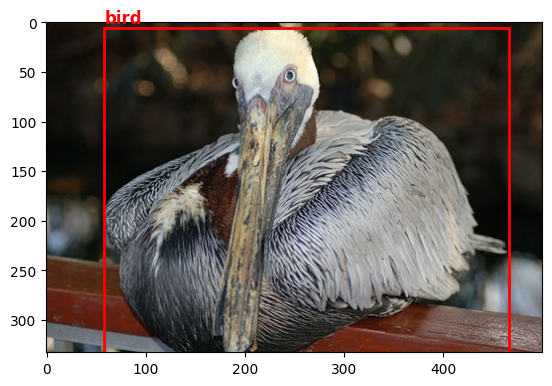

In [26]:
img_array = np.array(img)
print(img_array.shape)

plot_image_with_annotations(img_array, annotation_dict)

In [27]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

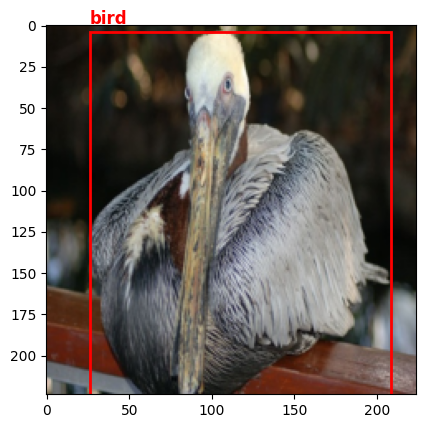

In [28]:
transformed_img = transform(img)

plot_image_with_annotations(transformed_img.permute(1, 2, 0).numpy(), annotation_dict, img_width=transformed_img.shape[2], img_height=transformed_img.shape[1])

In [54]:
from torch.utils.data import Dataset

class VOCDataset(Dataset):
    def __init__(self, img_paths_list, transform=None):
        self.img_paths_list = img_paths_list
        self.transform = transform

    def __len__(self):
        return len(self.img_paths_list)
    
    def __getitem__(self, idx):
        img_path = self.img_paths_list[idx]
        annotation_path = img_path.parents[1] / "Annotations" / (img_path.stem + ".xml")

        img = Image.open(img_path)
        annotation_dict = voc_to_dict(annotation_path)

        if self.transform:
            img = self.transform(img)
        
        return img, annotation_dict

In [55]:
voc2007_dataset = VOCDataset(voc2007_img_paths_list, transform=transform)
print(f"Length of VOC2007 dataset: {len(voc2007_dataset)}")
print(f"Sample from VOC2007 dataset: {voc2007_dataset[1][0].shape, voc2007_dataset[1][1]}")

Length of VOC2007 dataset: 9963
Sample from VOC2007 dataset: (torch.Size([3, 224, 224]), {'filename': '000143.jpg', 'size': {'width': 500.0, 'height': 333.0, 'depth': 3}, 'objects': [{'name': 'cat', 'class_idx': 7, 'bndbox': {'x_c': 0.67, 'y_c': 0.5690690690690691, 'width': 0.66, 'height': 0.8618618618618619}}]})


In [56]:
import torch

def collate_fn(batch):
    data = [item[0] for item in batch]
    targets = [item[1] for item in batch]

    return torch.stack(data, dim=0), targets

In [57]:
from torch.utils.data import DataLoader

train_loader = DataLoader(voc2007_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

In [58]:
img, annotation = next(iter(train_loader))
img.shape, annotation

(torch.Size([32, 3, 224, 224]),
 [{'filename': '008222.jpg',
   'size': {'width': 333.0, 'height': 500.0, 'depth': 3},
   'objects': [{'name': 'dog',
     'class_idx': 11,
     'bndbox': {'x_c': 0.487987987987988,
      'y_c': 0.52,
      'width': 0.6816816816816816,
      'height': 0.648}}]},
  {'filename': '003530.jpg',
   'size': {'width': 500.0, 'height': 375.0, 'depth': 3},
   'objects': [{'name': 'sofa',
     'class_idx': 17,
     'bndbox': {'x_c': 0.365,
      'y_c': 0.7546666666666667,
      'width': 0.722,
      'height': 0.49066666666666664}},
    {'name': 'person',
     'class_idx': 14,
     'bndbox': {'x_c': 0.382, 'y_c': 0.656, 'width': 0.74, 'height': 0.688}}]},
  {'filename': '007331.jpg',
   'size': {'width': 500.0, 'height': 375.0, 'depth': 3},
   'objects': [{'name': 'cat',
     'class_idx': 7,
     'bndbox': {'x_c': 0.486, 'y_c': 0.5, 'width': 0.956, 'height': 0.984}}]},
  {'filename': '006534.jpg',
   'size': {'width': 400.0, 'height': 280.0, 'depth': 3},
   'object